# Predicting the Probability of Something Occuring

With a linear regression, we were attempting to predict a response variable (y) with some predictor variable (X). 

$$ y = \beta_0 + \beta_1 X $$

What if we wanted to create a linear regression to predict the **probability** of something either occuring (Y=1) or not occuring (Y=0) based on some predictor variables $X$? 

$$p(X) = Pr(Y=1 \, | \, X)$$

which we read as "The probability of the response variable $y$ occuring given predictor variable $X$"

The linear regression will not work, so we need a function with properties better suited to probabilities...

## Standard Logistic Function

The standard logistic function is defined as:

$$ y = \frac{e^x}{1+e^x} $$

This appears as an "s" shape and is also known as a sigmoid curve.

*Note this is NOT the logarithmic function!*

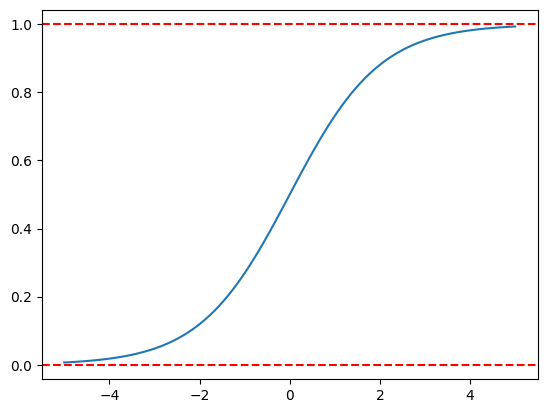

In [6]:
import numpy as np
import math
from scipy.stats import logistic
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 1)
x = np.linspace(-5, 5, 100)
logistic_y = ( math.e**x ) / (1 + math.e**x)
ax.plot(x, logistic_y)
plt.axhline(y=0, color='r', linestyle='--')
plt.axhline(y=1, color='r', linestyle='--')

## Logistic Regression

The standard logistic curve takes continuous values and returns values bounded between 0 and 1, making it perfect to take continuous predictor variables and output a probability based on those predictors. 

$$ P(X) = \frac{e^{\beta_0 + \beta_1 X}}{1+e^{\beta_0 + \beta_1 X}} $$

### Reasoning Behind Logisitic Regression Equation

Why set up the linear regression as the variable in the logisitic regression? Let's try to solve for $e^{\beta_0 + \beta_1 X}$ and see what happens. Let's start by noticing something about $\frac{1}{P(X)}$.

$$ \frac{1}{P(X)} = \frac{1+e^{\beta_0 + \beta_1 X}}{e^{\beta_0 + \beta_1 X}} = \frac{1}{e^{\beta_0 + \beta_1 X}} + 1 $$

We only have one $e^{\beta_0 + \beta_1 X}$ term now! So we can solve for it. 

$$ \frac{1}{P(X)} - 1 = \frac{1}{e^{\beta_0 + \beta_1 X}} $$

Combine the left side into a single fraction:

$$ \frac{1-P(X)}{P(X)} = \frac{1}{e^{\beta_0 + \beta_1 X}} $$

And flip the fractions to solve for $e^{\beta_0 + \beta_1 X}$:

$$ \frac{P(X)}{1-P(X)} = e^{\beta_0 + \beta_1 X} $$

Now we can take the logarithm of both sides to arrive at our linear regression:

$$ \log \left( \frac{P(X)}{1-P(X)} \right) = \beta_0 + \beta_1 X $$

The left side is called the *log odds* or *logit*, which is why the logistic regression is sometimes shorthanded to the *logit* regression. 

We can then set a cutoff probability and assign values to the left of the cutoff as "0" and to the right of the cutoff as "1".

### Estimating Logistic Regression Coefficients - Maximum Likelihood

While we may be inclined to see if the ordinary least squares (OLS) method would work here, a more common method called *maximum likelihood* can be used. Similar to the OLS method, we'd crete a "likelihood" function, taking the derivative, setting it equal to 0, and solving for the maximum. The mathematics behind how to do this is beyond even an introductory graduate-level Data Science course, so we won't touch it. 

## Maximum Likelihood Regression Results

Python and Excel will again run the full results for you. Let's use the diabetes data to test how this looks.

### Prepare Data

In [20]:
import numpy as np
import pandas as pd
import os

from statsmodels.formula.api import logit
import statsmodels.api as sm

diabetes_file_path = os.path.join(os.getcwd(), 'datasets', 'Diabetes_and_LifeStyle_Dataset.csv')
diabetes_df = pd.read_csv(diabetes_file_path)

diabetes_response_var = diabetes_df['diagnosed_diabetes']
# For now, we will take numeric variables only
numeric_vars = ['Age', 'alcohol_consumption_per_week',
       'physical_activity_minutes_per_week', 'diet_score',
       'sleep_hours_per_day', 'screen_time_hours_per_day',
       'family_history_diabetes', 'hypertension_history',
       'cardiovascular_history', 'bmi', 'waist_to_hip_ratio', 'systolic_bp',
       'diastolic_bp', 'heart_rate', 'cholesterol_total', 'hdl_cholesterol',
       'ldl_cholesterol', 'triglycerides', 'glucose_fasting',
       'glucose_postprandial', 'insulin_level', 'hba1c',
       'diabetes_risk_score']
diabetes_predictor_vars = diabetes_df[numeric_vars]

### Build Logit Regression

In [22]:
diabetes_predictor_vars_with_constant = sm.add_constant(diabetes_predictor_vars)
logit_model = sm.Logit(diabetes_response_var, diabetes_predictor_vars_with_constant)
logit_regression = logit_model.fit()

Optimization terminated successfully.
         Current function value: 0.347636
         Iterations 8


### Logit Regression Summary

In [23]:
logit_regression.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:     diagnosed_diabetes   No. Observations:                97297
Model:                          Logit   Df Residuals:                    97273
Method:                           MLE   Df Model:                           23
Date:                Tue, 14 Jul 2026   Pseudo R-squ.:                  0.4835
Time:                        14:49:16   Log-Likelihood:                -33824.
converged:                       True   LL-Null:                       -65480.
Covariance Type:            nonrobust   LLR p-value:                     0.000
======================================================================================================
                                         coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------------
const                                -24.0263      0.338    -71.056      0.000     -24.689     -23.364
Age                                    0.0003      0.003      0.086      0.931      -0.006       0.007
alcohol_consumption_per_week          -0.0094      0.007     -1.365      0.172      -0.023       0.004
physical_activity_minutes_per_week    -0.0001      0.000     -0.345      0.730      -0.001       0.001
diet_score                             0.0017      0.008      0.215      0.830      -0.014       0.018
sleep_hours_per_day                   -0.0083      0.009     -0.939      0.348      -0.026       0.009
screen_time_hours_per_day             -0.0044      0.005     -0.870      0.384      -0.014       0.006
family_history_diabetes                0.0345      0.191      0.181      0.857      -0.340       0.409
hypertension_history                  -0.0133      0.023     -0.585      0.558      -0.058       0.031
cardiovascular_history                 0.0502      0.037      1.364      0.173      -0.022       0.122
bmi                                   -0.0002      0.007     -0.032      0.974      -0.014       0.014
waist_to_hip_ratio                     0.3902      0.320      1.218      0.223      -0.238       1.018
systolic_bp                            0.0007      0.001      0.783      0.433      -0.001       0.002
diastolic_bp                          -0.0015      0.001     -1.252      0.210      -0.004       0.001
heart_rate                            -0.0004      0.001     -0.325      0.745      -0.003       0.002
cholesterol_total                     -0.0004      0.001     -0.472      0.637      -0.002       0.001
hdl_cholesterol                       -0.0006      0.002     -0.349      0.727      -0.004       0.003
ldl_cholesterol                        0.0009      0.001      0.973      0.331      -0.001       0.003
triglycerides                          0.0002      0.000      0.643      0.520      -0.000       0.001
glucose_fasting                        0.0154      0.001     14.025      0.000       0.013       0.018
glucose_postprandial                 4.47e-05      0.001      0.050      0.960      -0.002       0.002
insulin_level                         -0.0007      0.002     -0.311      0.756      -0.005       0.004
hba1c                                  3.4236      0.043     79.129      0.000       3.339       3.508
diabetes_risk_score                    0.0236      0.012      1.993      0.046       0.000       0.047
======================================================================================================
"""

Like the Linear Regression summary, we have a table with our predictor variables, their coefficients, and a t-test for each. Scanning through the list we see some predictors that we would definitely reject that they are independent from predicting diabetes: *glucose_fasting* and *hba1c*. For an alpha of 0.05 we would also reject independence for *diabetes_risk_score*.

Let's quickly build another model with just these 3 predictors to compare the Log-Likelihood (since all we know is we want to maximize it). 

### Second Logisitic Regression

In [25]:
stat_sig_predictor_names = ['glucose_fasting', 'hba1c', 'diabetes_risk_score']
diabetes_stat_sig_predictor_vars = diabetes_df[stat_sig_predictor_names]

stat_sig_predictor_vars_with_constant = sm.add_constant(diabetes_stat_sig_predictor_vars)
stat_sig_logit_model = sm.Logit(diabetes_response_var, stat_sig_predictor_vars_with_constant)
stat_sig_logit_regression = stat_sig_logit_model.fit()

stat_sig_logit_regression.summary()

Optimization terminated successfully.
         Current function value: 0.347726
         Iterations 8


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:     diagnosed_diabetes   No. Observations:                97297
Model:                          Logit   Df Residuals:                    97293
Method:                           MLE   Df Model:                            3
Date:                Tue, 14 Jul 2026   Pseudo R-squ.:                  0.4833
Time:                        14:59:26   Log-Likelihood:                -33833.
converged:                       True   LL-Null:                       -65480.
Covariance Type:            nonrobust   LLR p-value:                     0.000
=======================================================================================
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                 -23.9450      0.160   -149.418      0.000     -24.259     -23.631
glucose_fasting         0.0154      0.001     14.417      0.000       0.013       0.018
hba1c                   3.4248      0.026    134.069      0.000       3.375       3.475
diabetes_risk_score     0.0267      0.001     21.432      0.000       0.024       0.029
=======================================================================================
"""

### Results

- **Pseudo R-squared**: While a logistic regression does not have a "true" R-squared, there is a way to create a comparative measure. As before this ranges from 0 to 1, and a score closer to 1 indicates a better model fit of the data. 
- **Log-Likelihood**: This is an error-like measure for logistic functions to measure how well the model's predicted probabilities line up with the actual observations. We'll use this to compare models to determine a "best" one. We'd like to minimize this error as much as possible.
- **LL-Null**: Like the F-test can be used to evaluate an entire linear regression, a *Log-Likelihood* (LL) test assumes the model only needs the constant coefficient. Our alternative is that including at least one of the predictor variables creates a better fitting predictive model. 
$$ P(X) = \frac{e^{\beta_0}}{1+e^{\beta_0}} $$
- **LLR p-value**: The *Log-Likelihood Ratio* (LLR) is the test statistic we create to find an associated p-value. 

In the case of our model here, we have statistically significant evidence that at least one of our predictor variables creates a better model than none. 